https://github.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/blob/main/solution.ipynb

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [2]:
def escalado(X):
    from scipy.stats import skew, kurtosis
    import pandas as pd

    #Valores estadísticos
    med=list(X.mean())##Media
    cv=list(X.std()/X.mean()*100)#Coeficiente variacion
    men=list(X.quantile(0.5))#Mediana

    #Asimetría
    asim=list(skew(X))
    ##Análisis valores
    asim_an=[]
    for x in asim:
        if x>-0.5 and x<0.5: #Simétria
            asim_an.append("Simétrica")
        elif x<-1 or x>1: #Asimétria alta
            asim_an.append("Asimétrica alta")
        else: #Asimetría moderada
            asim_an.append("Asimétrica moderada")
    
    #Curtosis
    cur=list(kurtosis(X))

    #Análisis
    cur_an=[]
    ##Análisis valores
    for x in cur:
        if x>-0.5 and x<0.5: #Normal
            cur_an.append("Mesocúrtica")
        elif x<-1 or x>1: # Dist. Plana
            cur_an.append("Platicúrtica")
        else: #Peso importante colas y reisgo de outliers
            cur_an.append("Leptocúrtica")

    #Método de escalado
    esc=[]
    #Recorremos variables
    for asi,cu in zip(asim_an, cur_an):
        if asi=="Simétrica":
            if cu=="Leptocúrtica" or cu=="Mesocúrtica":  #Standar scaler
                esc.append("StandardScaler")
            else: #Robust scaler
                esc.append("RobustScaler")
        else: #Robust scaler
            esc.append("RobustScaler")

    return pd.DataFrame([med, men, cv, asim, asim_an, cur, cur_an, esc], 
             columns=X.columns, 
             index=["Media", "Mediana", "Coef. Var.", "Asimetría", "Asimetría Int.", "Curtosis", "Curtosis Int.", "Escalado"]).T

# **0. CONTEXTO Y CARGA DATOS**

**Objetivo**:

Entrena un modelo de K-Vecinos más Cercanos (KNN) para predecir la calidad de un vino tinto a partir de sus características químicas. ¿Podría una IA ayudarte a elegir un vino digno de sommelier?

**Descripción de la variables**: 

- fixed acidity, volatile acidity, citric acid

- residual sugar, chlorides

- free sulfur dioxide, total sulfur dioxide

- density, pH, sulphates, alcohol

In [3]:
#Cargamos la base de datos en crudo
df=pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv", sep=";")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
df.head(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.0,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5


# 1. Entrenamiento modelo KNN

## 1.1. Variables fundamentales

In [6]:
df["quality"].value_counts(normalize=True).sort_index()

quality
3    0.006254
4    0.033146
5    0.425891
6    0.398999
7    0.124453
8    0.011257
Name: proportion, dtype: float64

In [8]:
def map(col):
    if col<=4: #Baja Calidad
        return 0
    elif col<=6:#Calidad media
        return 1
    else: #Alta calidad
        return 2

#Aplicamos mapeo para la crear la variable objetivo (ejecuta la funcion valor a valor)
df["label"]=df["quality"].apply(map)

In [10]:
#Definimos variables del modelo
X=df.drop(columns=["label", "quality"])
y=df["label"]

#Divisimos la base de datos
X_train,X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## 1.2. Escalado

In [11]:
#Resumen de la distribución de las variables independientes
escalado(X_train)

,Media,Mediana,Coef. Var.,Asimetría,Asimetría Int.,Curtosis,Curtosis Int.,Escalado
fixed acidity,8.32369,7.9,20.714887,0.963375,Asimétrica moderada,1.088057,Platicúrtica,RobustScaler
volatile acidity,0.530559,0.52,33.789877,0.743855,Asimétrica moderada,1.496531,Platicúrtica,RobustScaler
citric acid,0.272471,0.26,71.731677,0.313537,Simétrica,-0.782635,Leptocúrtica,StandardScaler
residual sugar,2.555473,2.2,56.184888,4.559174,Asimétrica alta,28.917736,Platicúrtica,RobustScaler
chlorides,0.088448,0.08,55.775611,5.564941,Asimétrica alta,39.365455,Platicúrtica,RobustScaler
free sulfur dioxide,15.876075,14.0,64.962636,1.197428,Asimétrica alta,1.816152,Platicúrtica,RobustScaler
total sulfur dioxide,46.657154,38.0,70.604311,1.383693,Asimétrica alta,2.756168,Platicúrtica,RobustScaler
density,0.996774,0.9968,0.186195,0.055736,Simétrica,1.080314,Platicúrtica,RobustScaler
pH,3.31165,3.31,4.650724,0.197556,Simétrica,0.712879,Leptocúrtica,StandardScaler
sulphates,0.660023,0.62,26.454306,2.588958,Asimétrica alta,12.560968,Platicúrtica,RobustScaler


Aplicaremos RobustScaler para homogenerizar las escalas en las variables ya que este modelo se basa en distancias.

In [31]:
# Instaciamos el escalador
rb_scal=RobustScaler()
# Ajustamos y transformamos para train
X_train_sc=pd.DataFrame(rb_scal.fit_transform(X_train), columns=X_train.columns)
# Solo transformamos para test (independia base datos)
X_test_sc=pd.DataFrame(rb_scal.transform(X_test), columns=X_test.columns)

## 1.3. Entrenamiento modelo

In [ ]:
# Instanciamos y entrenamos el modelo
model = KNeighborsClassifier(n_neighbors=5, #Vecinos más cercanos
                             metric='minkowski', #métrica lineal
                             p=2) #euclidiana
model.fit(X_train_sc, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


# 2. Evaluación modelo KNN

accuracy_score

confusion_matrix

classification_report 

In [42]:
# Realizamos las predicciones
y_hat_train=model.predict(X_train_sc)
y_hat_test=model.predict(X_test_sc)

In [51]:
#Accuracy
print("Porcentaje total de clasificados correctamente:", round(accuracy_score(y_test, y_hat_test)*100,2))

Porcentaje total de clasificados correctamente: 83.44


DISTRIBUCIÓN OBSERVADA: {0: 11, 1: 262, 2: 47}


[]

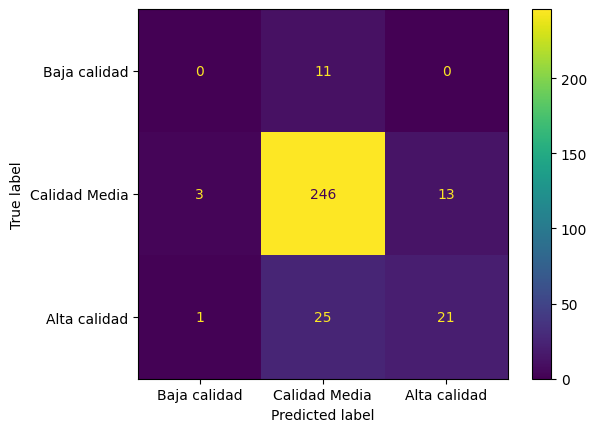

In [71]:
#Matriz de confusion
print(f"DISTRIBUCIÓN OBSERVADA: {y_test.value_counts().sort_index().to_dict()}")
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_hat_test),  display_labels=["Baja calidad", "Calidad Media", "Alta calidad"])
disp.plot()
plt.plot()

In [73]:
#Resumen de las metricas de clasificacion
print("\nMétricas de clasificación:\n", classification_report(y_test, y_hat_test))


Métricas de clasificación:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.87      0.94      0.90       262
           2       0.62      0.45      0.52        47

    accuracy                           0.83       320
   macro avg       0.50      0.46      0.47       320
weighted avg       0.80      0.83      0.82       320

